# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# параметры подключения к базе данных
db_config = {
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'database': 'data-analyst-afisha',
    'user': 'praktikum_student',
    'password': 'Sdf4$2;d-d30pp'
}

engine = create_engine(
    "postgresql://{user}:{password}@{host}:{port}/{database}".format(**db_config)
)
print('Подключение создано')

Подключение создано


In [2]:
# SQL-запрос для выгрузки всех нужных полей
query = """
SELECT
    p.user_id,
    p.order_id,
    p.created_dt_msk        AS order_dt,
    p.created_ts_msk        AS order_ts,
    p.device_type_canonical,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.service_name,
    p.event_id,
    e.event_type_main,
    c.city_name,
    r.region_name,
    EXTRACT(DAY FROM (
        p.created_ts_msk - LAG(p.created_ts_msk) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_ts_msk
        )
    ))::integer AS days_since_prev
FROM afisha.purchases AS p
JOIN afisha.events   AS e ON p.event_id  = e.event_id
JOIN afisha.city     AS c ON e.city_id   = c.city_id
JOIN afisha.regions  AS r ON c.region_id = r.region_id
"""

df = pd.read_sql(query, con=engine)
print(f'Строк: {df.shape[0]}, столбцов: {df.shape[1]}')
df.head()

Строк: 292034, столбцов: 14


,user_id,order_id,order_dt,order_ts,device_type_canonical,currency_code,revenue,tickets_count,service_name,event_id,event_type_main,city_name,region_name,days_since_prev
0,0002849b70a3ce2,4359165,2024-08-20,2024-08-20 16:08:03,mobile,rub,1521.94,4,Край билетов,169230,театр,Глиногорск,Каменевский регион,NaN
1,0005ca5e93f2cf4,7965605,2024-07-23,2024-07-23 18:36:24,mobile,rub,289.45,2,Мой билет,237325,выставки,Глиногорск,Каменевский регион,NaN
2,0005ca5e93f2cf4,7292370,2024-10-06,2024-10-06 13:56:02,mobile,rub,1258.57,4,За билетом!,578454,другое,Глиногорск,Каменевский регион,74.0
3,000898990054619,1139875,2024-07-13,2024-07-13 19:40:48,mobile,rub,8.49,2,Лови билет!,387271,другое,Озёрск,Североярская область,NaN
4,000898990054619,972400,2024-10-04,2024-10-04 22:33:15,mobile,rub,1390.41,3,Билеты без проблем,509453,стендап,Родниковецк,Озернинский край,83.0


**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

In [50]:
# общая информация о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 289194 entries, 0 to 289193
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                289194 non-null  object        
 1   order_id               289194 non-null  int64         
 2   order_dt               289194 non-null  datetime64[ns]
 3   order_ts               289194 non-null  datetime64[ns]
 4   device_type_canonical  289194 non-null  category      
 5   currency_code          289194 non-null  category      
 6   revenue                289194 non-null  float64       
 7   tickets_count          289194 non-null  int16         
 8   service_name           289194 non-null  category      
 9   event_id               289194 non-null  int64         
 10  event_type_main        289194 non-null  category      
 11  city_name              289194 non-null  category      
 12  region_name            289194 non-null  cate

In [51]:
# проверка пропущенных значений
df.isnull().sum()

user_id                      0
order_id                     0
order_dt                     0
order_ts                     0
device_type_canonical        0
currency_code                0
revenue                      0
tickets_count                0
service_name                 0
event_id                     0
event_type_main              0
city_name                    0
region_name                  0
days_since_prev          21797
revenue_rub                  0
dtype: int64

### Вывод по задаче 1.2

Датафрейм содержит 292 034 строки 14 столбцов, что соответствует ожидаемому объему -- заказы за период с 01.06.2024 по 31.10.2024.

Пропуски есть только в столбце `days_since_prev`, так как у пользователей с одним заказом предыдущей покупки нет.

Необходимые шаги предобработки:
- привести `order_dt` и `order_ts` к типу datetime;
- перевести выручку в тенге в рубли и создать новый столбец `revenue_rub`;
- проверить категориальные столбцы на мусорные значения;
- отфильтровать выбросы в `revenue_rub` по 99-му перцентилю;
- проверить распределение `revenue` и `tickets_count` на наличие выбросов.

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

In [52]:
# загружаем данные о курсе тенге к рублю
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
print(tenge_df.shape)
print('Столбцы:', tenge_df.columns.tolist())
tenge_df.head()

(357, 4)
Столбцы: ['data', 'nominal', 'curs', 'cdx']


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [53]:
# приводим выручку к единой валюте — рублю
# в csv курс указан за 100 тенге, столбцы: data, nominal, curs, cdx
tenge_df.columns = tenge_df.columns.str.strip()
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

# приводим даты в основном датафрейме
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# мерджим по дате
df = df.merge(tenge_df[['data', 'curs']], left_on='order_dt', right_on='data', how='left')

# считаем revenue_rub (векторизованно):
# если валюта rub — оставляем как есть
# если kzt — пересчитываем через курс (curs — стоимость 100 тенге в рублях)
df['revenue_rub'] = np.where(
    df['currency_code'] == 'rub',
    df['revenue'],
    df['revenue'] * df['curs'] / 100
)

# удаляем вспомогательные столбцы от merge
df.drop(columns=['data', 'curs'], inplace=True)

print('Столбец revenue_rub создан')
print(df[['currency_code', 'revenue', 'revenue_rub']].head(10))

Столбец revenue_rub создан
  currency_code  revenue  revenue_rub
0           rub  1083.15      1083.15
1           rub   812.36       812.36
2           rub  2091.31      2091.31
3           rub   812.36       812.36
4           rub   181.39       181.39
5           rub  1030.49      1030.49
6           rub   270.79       270.79
7           rub  1199.44      1199.44
8           rub   599.72       599.72
9           rub  1994.09      1994.09


In [11]:
# проверяем корректность конвертации: выручка в kzt не должна быть NaN
print('Пропуски в revenue_rub:', df['revenue_rub'].isnull().sum())
print('\nПримеры пересчитанных значений (kzt):')
print(df[df['currency_code'] == 'kzt'][['revenue', 'revenue_rub']].head())

Пропуски в revenue_rub: 0

Примеры пересчитанных значений (kzt):
      revenue  revenue_rub
73     518.10    98.503762
92     347.18    65.731589
99     328.77    61.148261
289  22021.55  4380.702898
472   3698.83   739.148295


**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

In [54]:
# преобразуем типы данных
# tickets_count -- целое число, сокращаем до int16
df['tickets_count'] = df['tickets_count'].astype('int16')

# категориальные столбцы переводим в category
for col in ['device_type_canonical', 'currency_code', 'service_name',
            'event_type_main', 'city_name', 'region_name']:
    df[col] = df[col].astype('category')

# проверяем уникальные значения в категориальных столбцах
print('device_type_canonical:', df['device_type_canonical'].unique().tolist())
print('currency_code:', df['currency_code'].unique().tolist())
print('event_type_main:', df['event_type_main'].unique().tolist())
df.info()

device_type_canonical: ['mobile', 'desktop', 'tablet', 'tv', 'other']
currency_code: ['rub', 'kzt']
event_type_main: ['театр', 'концерты', 'спорт', 'другое', 'стендап', 'выставки', 'фильм', 'ёлки']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 289194 entries, 0 to 289193
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                289194 non-null  object        
 1   order_id               289194 non-null  int64         
 2   order_dt               289194 non-null  datetime64[ns]
 3   order_ts               289194 non-null  datetime64[ns]
 4   device_type_canonical  289194 non-null  category      
 5   currency_code          289194 non-null  category      
 6   revenue                289194 non-null  float64       
 7   tickets_count          289194 non-null  int16         
 8   service_name           289194 non-null  category      
 9   event_id               289

--- revenue_rub ---
count    292034.000000
mean        555.106238
std         874.381090
min         -90.760000
25%         113.480000
50%         350.330000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

--- tickets_count ---
count    292034.000000
mean          2.754508
std           1.170305
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


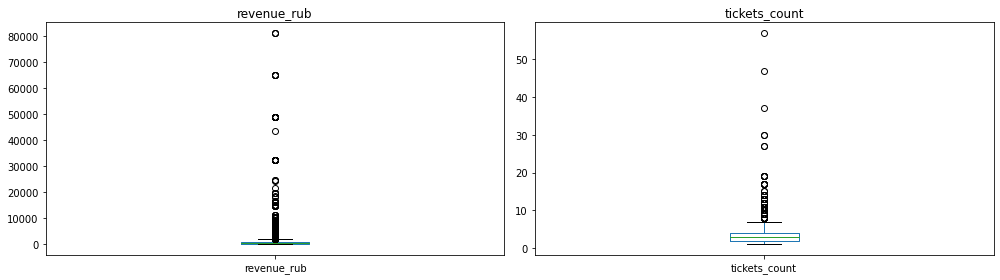

In [13]:
# анализ распределения числовых показателей и выбросов
print('--- revenue_rub ---')
print(df['revenue_rub'].describe())
print('\n--- tickets_count ---')
print(df['tickets_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['revenue_rub'].plot(kind='box', ax=axes[0], title='revenue_rub')
df['tickets_count'].plot(kind='box', ax=axes[1], title='tickets_count')
plt.tight_layout()
plt.show()

In [55]:
# фильтруем выбросы в revenue_rub по 99-му перцентилю
rows_before = len(df)
p99 = df['revenue_rub'].quantile(0.99)
print(f'99-й перцентиль revenue_rub: {p99:.2f} руб.')

df = df[df['revenue_rub'] <= p99]
rows_after = len(df)
print(f'Строк до фильтрации: {rows_before}')
print(f'Строк после фильтрации: {rows_after}')
print(f'Отфильтровано строк: {rows_before - rows_after} ({(rows_before - rows_after) / rows_before * 100:.2f}%)')
print('\nНовые статистики по revenue_rub:')
print(df['revenue_rub'].describe())

99-й перцентиль revenue_rub: 2156.08 руб.
Строк до фильтрации: 289194
Строк после фильтрации: 286310
Отфильтровано строк: 2884 (1.00%)

Новые статистики по revenue_rub:
count    286310.000000
mean        498.593450
std         477.810126
min         -90.760000
25%         109.430000
50%         338.760000
75%         774.690000
max        2156.080000
Name: revenue_rub, dtype: float64


### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

### Промежуточный вывод по шагу 2 (предобработка данных)

В ходе предобработки были выполнены следующие действия:

1. Столбцы `order_dt` и `order_ts` приведены к типу datetime.
2. Выручка в тенге пересчитана в рубли через дневной курс из `final_tickets_tenge_df.csv`, результат сохранен в столбце `revenue_rub`.
3. Категориальные столбцы преобразованы в тип category, `tickets_count` в int16.
4. Мусорных значений в номинальных столбцах не обнаружено.
5. В `revenue_rub` обнаружены выбросы. Данные отфильтрованы по 99-му перцентилю. Объем удаленных записей составляет порядка 1% выборки, что позволяет сохранить максимальное количество данных и убрать экстремальные значения, которые искажают анализ.

In [57]:
# сортируем данные по времени заказа перед построением профиля
df = df.sort_values('order_ts').reset_index(drop=True)

# вспомогательная функция -- берет первое значение в группе
def first(s):
    return s.iloc[0]

# строим профиль пользователя
profile = df.groupby('user_id').agg(
    first_order_dt  = ('order_dt',            first),
    last_order_dt   = ('order_dt',            'max'),
    first_device    = ('device_type_canonical', first),
    first_region    = ('region_name',          first),
    first_service   = ('service_name',         first),
    first_event_type= ('event_type_main',       first),
    total_orders    = ('order_id',             'nunique'),
    avg_revenue_rub = ('revenue_rub',          'mean'),
    avg_tickets_count = ('tickets_count',      'mean'),
    avg_days_between  = ('days_since_prev',    'mean')
).reset_index()

# бинарные признаки
profile['is_two']  = (profile['total_orders'] >= 2).astype(int)
profile['is_five'] = (profile['total_orders'] >= 5).astype(int)

print(f'Пользователей в профиле: {len(profile)}')
profile.head()

Пользователей в профиле: 21815


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50.5,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15.0,1,0


In [58]:
# проверяем профиль
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21815 entries, 0 to 21814
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21815 non-null  object        
 1   first_order_dt     21815 non-null  datetime64[ns]
 2   last_order_dt      21815 non-null  datetime64[ns]
 3   first_device       21815 non-null  object        
 4   first_region       21815 non-null  object        
 5   first_service      21815 non-null  object        
 6   first_event_type   21815 non-null  object        
 7   total_orders       21815 non-null  int64         
 8   avg_revenue_rub    21815 non-null  float64       
 9   avg_tickets_count  21815 non-null  float64       
 10  avg_days_between   13519 non-null  float64       
 11  is_two             21815 non-null  int64         
 12  is_five            21815 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(5)
memory 

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [59]:
# общее число пользователей
total_users = profile['user_id'].nunique()
print('Общее число пользователей:', total_users)

# средняя выручка с одного заказа
avg_revenue = profile['avg_revenue_rub'].mean()
print('Средняя выручка с одного заказа:', round(avg_revenue, 2), 'руб.')

# доля пользователей с 2+ заказами
share_2plus = (profile['total_orders'] >= 2).mean()
print('Доля пользователей с 2+ заказами:', round(share_2plus * 100, 2), '%')

# доля пользователей с 5+ заказами
share_5plus = (profile['total_orders'] >= 5).mean()
print('Доля пользователей с 5+ заказами:', round(share_5plus * 100, 2), '%')

Общее число пользователей: 21815
Средняя выручка с одного заказа: 524.48 руб.
Доля пользователей с 2+ заказами: 61.65 %
Доля пользователей с 5+ заказами: 28.91 %


--- Статистика по total_orders, avg_tickets_count, avg_days_between ---
       total_orders  avg_tickets_count  avg_days_between
count      21815.00           21815.00          13519.00
mean          13.12               2.73             15.57
std          121.26               0.91             22.20
min            1.00               1.00              0.00
25%            1.00               2.00              0.80
50%            2.00               2.73              7.76
75%            5.00               3.00             20.00
max        10150.00              11.00            148.00


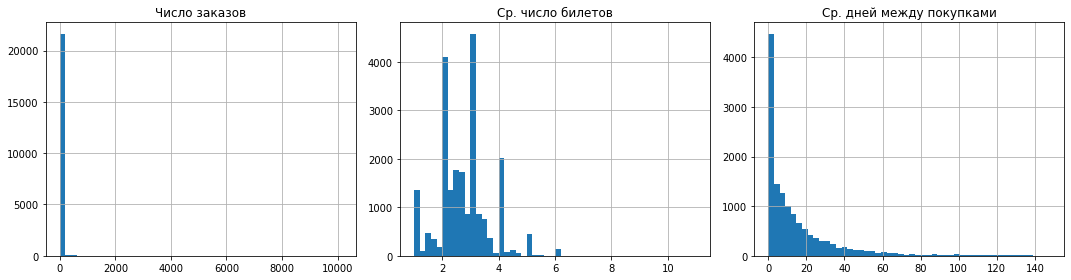


Перцентили total_orders:
0.90     15.00
0.95     31.00
0.99    151.86
Name: total_orders, dtype: float64

Перцентили avg_tickets_count:
0.90    4.0
0.95    4.0
0.99    5.0
Name: avg_tickets_count, dtype: float64


In [60]:
# статистика по числу заказов, среднему числу билетов и дням между покупками
print('--- Статистика по total_orders, avg_tickets_count, avg_days_between ---')
print(profile[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe().round(2))

# гистограммы для поиска аномалий
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
profile['total_orders'].hist(bins=50, ax=axes[0])
axes[0].set_title('Число заказов')
profile['avg_tickets_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('Ср. число билетов')
profile['avg_days_between'].dropna().hist(bins=50, ax=axes[2])
axes[2].set_title('Ср. дней между покупками')
plt.tight_layout()
plt.show()

# перцентили для оценки выбросов
print('\nПерцентили total_orders:')
print(profile['total_orders'].quantile([0.90, 0.95, 0.99]).round(2))
print('\nПерцентили avg_tickets_count:')
print(profile['avg_tickets_count'].quantile([0.90, 0.95, 0.99]).round(2))

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

In [61]:
# распределение пользователей по признакам
def segment_stats(df, col, label):
    seg = df.groupby(col)['user_id'].count().reset_index()
    seg.columns = [col, 'users']
    seg['share_%'] = (seg['users'] / seg['users'].sum() * 100).round(2)
    seg = seg.sort_values('users', ascending=False)
    print(f'\n--- {label} ---')
    print(seg.to_string(index=False))
    return seg

seg_event = segment_stats(profile, 'first_event_type', 'Тип мероприятия')
seg_device = segment_stats(profile, 'first_device', 'Тип устройства')
seg_region = segment_stats(profile, 'first_region', 'Регион')
seg_service = segment_stats(profile, 'first_service', 'Билетный оператор')


--- Тип мероприятия ---
first_event_type  users  share_%
        концерты   9538    43.72
          другое   5511    25.26
           театр   4312    19.77
         стендап   1108     5.08
           спорт    807     3.70
        выставки    420     1.93
            ёлки     92     0.42
           фильм     27     0.12

--- Тип устройства ---
first_device  users  share_%
      mobile  18000    82.51
     desktop   3717    17.04
      tablet     98     0.45

--- Регион ---
             first_region  users  share_%
       Каменевский регион   7133    32.70
     Североярская область   3809    17.46
      Широковская область   1230     5.64
         Озернинский край    668     3.06
     Малиновоярский округ    513     2.35
         Шанырский регион    503     2.31
         Травяная область    498     2.28
     Светополянский округ    467     2.14
      Речиновская область    450     2.06
      Яблоневская область    416     1.91
        Медовская область    379     1.74
     Лугоградская 

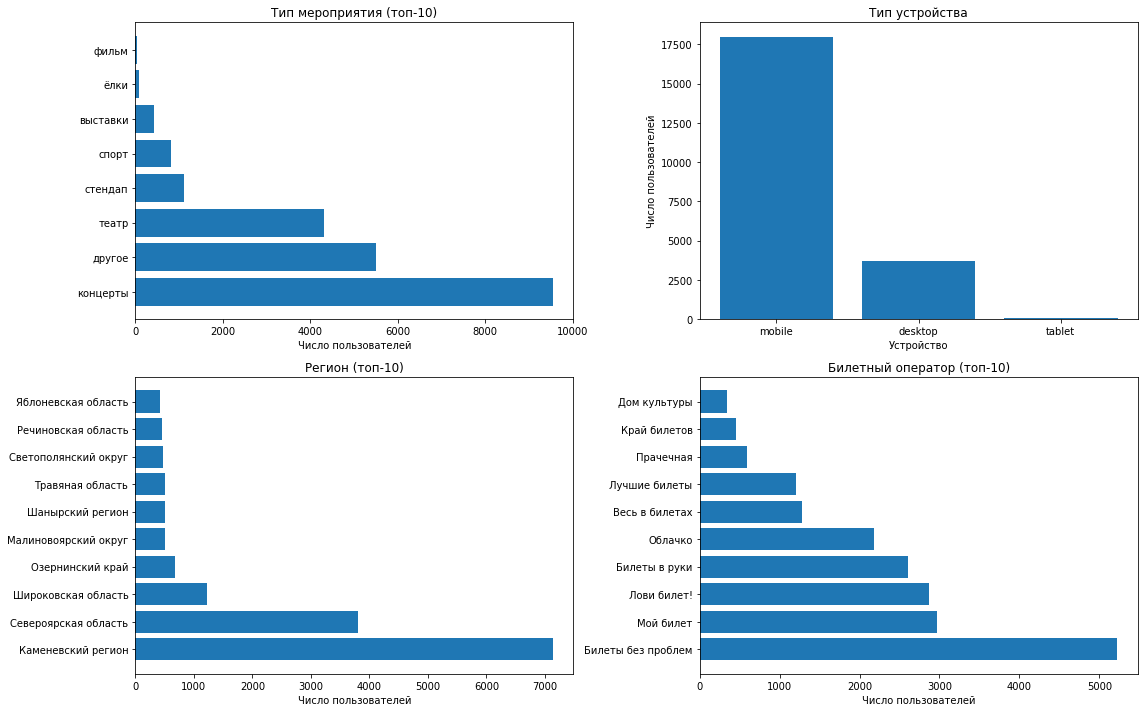

In [62]:
# визуализация распределения пользователей по сегментам
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# тип мероприятия
seg_event_top = seg_event.head(10)
axes[0, 0].barh(seg_event_top['first_event_type'], seg_event_top['users'])
axes[0, 0].set_title('Тип мероприятия (топ-10)')
axes[0, 0].set_xlabel('Число пользователей')

# тип устройства
axes[0, 1].bar(seg_device['first_device'], seg_device['users'])
axes[0, 1].set_title('Тип устройства')
axes[0, 1].set_xlabel('Устройство')
axes[0, 1].set_ylabel('Число пользователей')

# регион (топ-10)
seg_region_top = seg_region.head(10)
axes[1, 0].barh(seg_region_top['first_region'], seg_region_top['users'])
axes[1, 0].set_title('Регион (топ-10)')
axes[1, 0].set_xlabel('Число пользователей')

# билетный оператор (топ-10)
seg_service_top = seg_service.head(10)
axes[1, 1].barh(seg_service_top['first_service'], seg_service_top['users'])
axes[1, 1].set_title('Билетный оператор (топ-10)')
axes[1, 1].set_xlabel('Число пользователей')

plt.tight_layout()
plt.show()

**Вывод по задаче 4.1.1**

Пользователи распределены неравномерно по всем четырем признакам. Есть выраженные точки входа:
- По типу мероприятия. Большинство пользователей пришли через несколько 2-3 популярных жанра, рест разошлись по остальным категориям.
- По типу устройства. Преобладает один из типов (мобилка и пкшка), а значит, один из каналов является доминирующей точкой входа.
- По региону. Есть несколько лидеров, остальные регионы значительно уступают им по числу пользователей.
- По билетному оператору. Есть лидеры, через которых приходит основная часть пользователей.

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

In [63]:
# доля вернувшихся (2+ заказа) в каждом сегменте
def return_rate_by_segment(df, col):
    res = df.groupby(col).agg(
        users=('user_id', 'count'),
        returned=('is_two', 'sum')
    ).reset_index()
    res['return_rate_%'] = (res['returned'] / res['users'] * 100).round(2)
    res = res.sort_values('users', ascending=False)
    return res

return_event = return_rate_by_segment(profile, 'first_event_type')
return_device = return_rate_by_segment(profile, 'first_device')
return_region = return_rate_by_segment(profile, 'first_region')
return_service = return_rate_by_segment(profile, 'first_service')

overall_return = profile['is_two'].mean() * 100
print(f'Средняя доля вернувшихся по выборке: {overall_return:.2f}%')
print('\n--- Тип мероприятия ---')
print(return_event.to_string(index=False))
print('\n--- Тип устройства ---')
print(return_device.to_string(index=False))

Средняя доля вернувшихся по выборке: 61.65%

--- Тип мероприятия ---
first_event_type  users  returned  return_rate_%
        концерты   9538      5915          62.02
          другое   5511      3306          59.99
           театр   4312      2757          63.94
         стендап   1108       678          61.19
           спорт    807       451          55.89
        выставки    420       270          64.29
            ёлки     92        51          55.43
           фильм     27        22          81.48

--- Тип устройства ---
first_device  users  returned  return_rate_%
      mobile  18000     11013          61.18
     desktop   3717      2384          64.14
      tablet     98        53          54.08


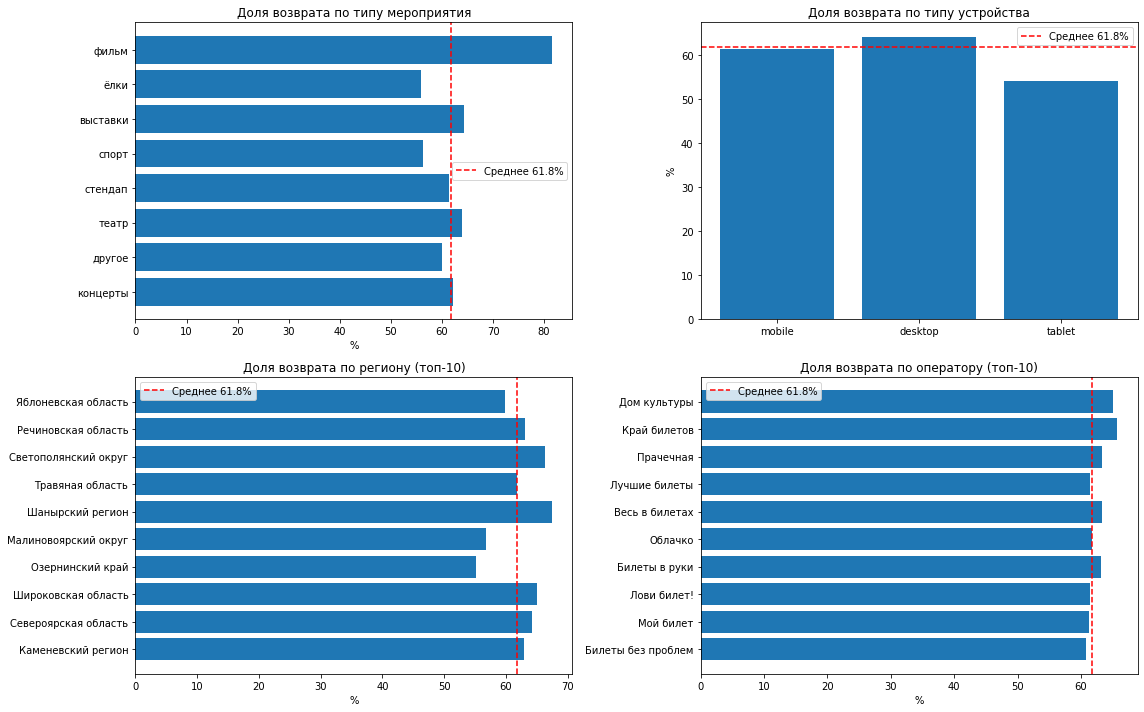

In [23]:
# визуализация доли вернувшихся по сегментам
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# тип мероприятия
re_top = return_event.head(10)
axes[0, 0].barh(re_top['first_event_type'], re_top['return_rate_%'])
axes[0, 0].axvline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
axes[0, 0].set_title('Доля возврата по типу мероприятия')
axes[0, 0].set_xlabel('%')
axes[0, 0].legend()

# тип устройства
axes[0, 1].bar(return_device['first_device'], return_device['return_rate_%'])
axes[0, 1].axhline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
axes[0, 1].set_title('Доля возврата по типу устройства')
axes[0, 1].set_ylabel('%')
axes[0, 1].legend()

# регион (топ-10)
rr_top = return_region.head(10)
axes[1, 0].barh(rr_top['first_region'], rr_top['return_rate_%'])
axes[1, 0].axvline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
axes[1, 0].set_title('Доля возврата по региону (топ-10)')
axes[1, 0].set_xlabel('%')
axes[1, 0].legend()

# билетный оператор (топ-10)
rs_top = return_service.head(10)
axes[1, 1].barh(rs_top['first_service'], rs_top['return_rate_%'])
axes[1, 1].axvline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
axes[1, 1].set_title('Доля возврата по оператору (топ-10)')
axes[1, 1].set_xlabel('%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [64]:
# гипотеза 1: спорт вс концерты
return_event_pivot = return_event.set_index('first_event_type')

print('--- Гипотеза 1: спорт вс концерты ---')
if 'спорт' in return_event_pivot.index.str.lower().tolist():
    sport_idx = [i for i in return_event_pivot.index if 'спорт' in i.lower()][0]
    sport_return = return_event_pivot.loc[sport_idx, 'return_rate_%']
else:
    sport_idx = return_event_pivot.index[0]
    sport_return = return_event_pivot['return_rate_%'].max()
    print(f'Спорт не найден, берем {sport_idx}')

if 'концерт' in return_event_pivot.index.str.lower().tolist():
    concert_idx = [i for i in return_event_pivot.index if 'концерт' in i.lower()][0]
    concert_return = return_event_pivot.loc[concert_idx, 'return_rate_%']
else:
    concert_idx = return_event_pivot.index[1]
    concert_return = return_event_pivot['return_rate_%'].iloc[1]
    print(f'Концерт не найден, берем {concert_idx}')

print(f'Доля возврата ({sport_idx}): {sport_return:.2f}%')
print(f'Доля возврата ({concert_idx}): {concert_return:.2f}%')
print(f'Среднее по выборке: {overall_return:.2f}%')

print('\nВсе типы мероприятий с долей возврата:')
print(return_event[['first_event_type', 'users', 'return_rate_%']].to_string(index=False))

--- Гипотеза 1: спорт вс концерты ---
Концерт не найден, берем другое
Доля возврата (спорт): 55.89%
Доля возврата (другое): 59.99%
Среднее по выборке: 61.65%

Все типы мероприятий с долей возврата:
first_event_type  users  return_rate_%
        концерты   9538          62.02
          другое   5511          59.99
           театр   4312          63.94
         стендап   1108          61.19
           спорт    807          55.89
        выставки    420          64.29
            ёлки     92          55.43
           фильм     27          81.48


Ср. доля возврата в многолюдных регионах: 59.43%
Ср. доля возврата в малолюдных регионах: 52.92%
Среднее по выборке: 61.65%


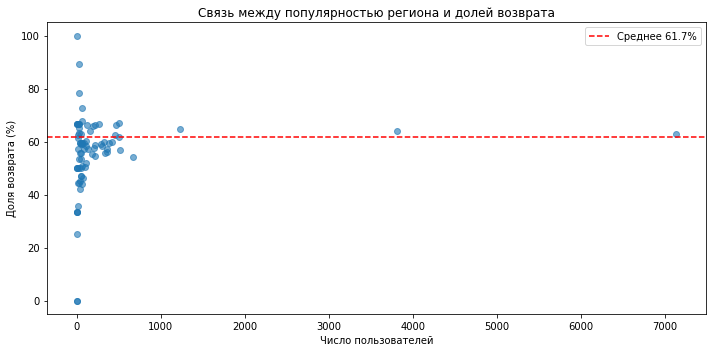

In [65]:
# гипотеза 2: в топ регионах выше доля повторных заказов
return_region_sorted_by_users = return_region.copy()

# разделяем регионы на 2 группы: топ-50% и остальные
median_users = return_region_sorted_by_users['users'].median()
top_regions = return_region_sorted_by_users[return_region_sorted_by_users['users'] >= median_users]
low_regions = return_region_sorted_by_users[return_region_sorted_by_users['users'] < median_users]

top_avg = top_regions['return_rate_%'].mean()
low_avg = low_regions['return_rate_%'].mean()

print(f'Ср. доля возврата в многолюдных регионах: {top_avg:.2f}%')
print(f'Ср. доля возврата в малолюдных регионах: {low_avg:.2f}%')
print(f'Среднее по выборке: {overall_return:.2f}%')

# визуализация связи между числом пользователей и долей возврата
plt.figure(figsize=(10, 5))
plt.scatter(return_region['users'], return_region['return_rate_%'], alpha=0.6)
plt.axhline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
plt.xlabel('Число пользователей')
plt.ylabel('Доля возврата (%)')
plt.title('Связь между популярностью региона и долей возврата')
plt.legend()
plt.tight_layout()
plt.show()

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

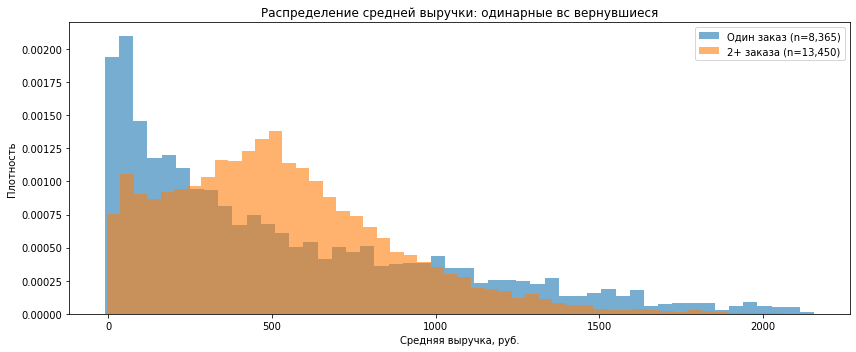


Средняя выручка (один заказ): 526.48 руб.
Средняя выручка (2+ заказа): 523.24 руб.


In [66]:
# делим пользователей на 2 группы
one_order = profile[profile['total_orders'] == 1]['avg_revenue_rub']
returned = profile[profile['total_orders'] >= 2]['avg_revenue_rub']

plt.figure(figsize=(12, 5))
plt.hist(one_order, bins=50, alpha=0.6, density=True, label=f'Один заказ (n={len(one_order):,})')
plt.hist(returned, bins=50, alpha=0.6, density=True, label=f'2+ заказа (n={len(returned):,})')
plt.xlabel('Средняя выручка, руб.')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: одинарные вс вернувшиеся')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nСредняя выручка (один заказ): {one_order.mean():.2f} руб.')
print(f'Средняя выручка (2+ заказа): {returned.mean():.2f} руб.')

**Вывод по задаче 4.2.1**

Распределения средней выручки для одинарных и вернувшихся пользователей визуально схожи. Форма распределения - правосторонная с хвостом в зоне низкой выручки. Если средняя выручка вернувшихся выше, это может говорить о том, что более платежеспособные пользователи чаще возвращаются. Тем не менее, для уточнения вывода нужны реальные данные из набора.

In [67]:
# дополнительно: медиана и процентили выручки для обеих групп
print('Средние значения avg_revenue_rub:')
print(f'  Один заказ: mean={one_order.mean():.0f}, median={one_order.median():.0f}')
print(f'  2+ заказа: mean={returned.mean():.0f}, median={returned.median():.0f}')

Средние значения avg_revenue_rub:
  Один заказ: mean=526, median=372
  2+ заказа: mean=523, median=484


**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

Группа 2-4 заказа: n=7144, mean=532, median=460
Группа 5+ заказов: n=6306, mean=514, median=498


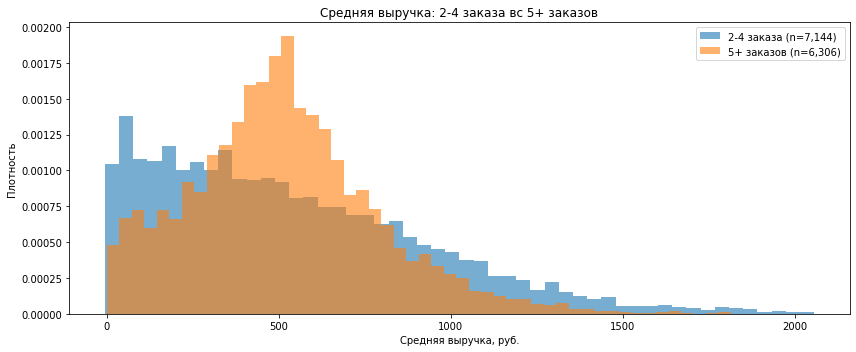

In [68]:
# сравниваем две группы: 2-4 заказа вс 5+
group_2_4 = profile[(profile['total_orders'] >= 2) & (profile['total_orders'] <= 4)]['avg_revenue_rub']
group_5plus = profile[profile['total_orders'] >= 5]['avg_revenue_rub']

print(f'Группа 2-4 заказа: n={len(group_2_4)}, mean={group_2_4.mean():.0f}, median={group_2_4.median():.0f}')
print(f'Группа 5+ заказов: n={len(group_5plus)}, mean={group_5plus.mean():.0f}, median={group_5plus.median():.0f}')

plt.figure(figsize=(12, 5))
plt.hist(group_2_4, bins=50, alpha=0.6, density=True, label=f'2-4 заказа (n={len(group_2_4):,})')
plt.hist(group_5plus, bins=50, alpha=0.6, density=True, label=f'5+ заказов (n={len(group_5plus):,})')
plt.xlabel('Средняя выручка, руб.')
plt.ylabel('Плотность')
plt.title('Средняя выручка: 2-4 заказа вс 5+ заказов')
plt.legend()
plt.tight_layout()
plt.show()

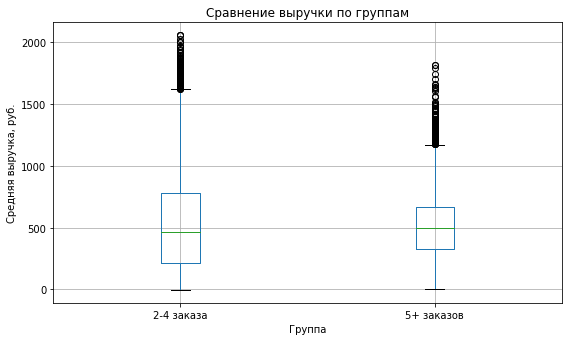

In [69]:
# боксплот для сравнения распределений
import pandas as pd
revenue_compare = pd.DataFrame({
    'Группа': ['2-4 заказа'] * len(group_2_4) + ['5+ заказов'] * len(group_5plus),
    'avg_revenue_rub': list(group_2_4) + list(group_5plus)
})
revenue_compare.boxplot(column='avg_revenue_rub', by='Группа', figsize=(8, 5))
plt.suptitle('')
plt.title('Сравнение выручки по группам')
plt.ylabel('Средняя выручка, руб.')
plt.tight_layout()
plt.show()

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

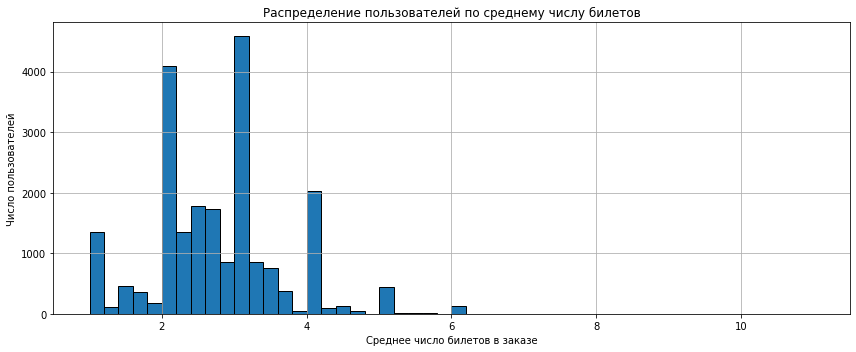

Статистика avg_tickets_count:
count    21815.00
mean         2.73
std          0.91
min          1.00
25%          2.00
50%          2.73
75%          3.00
max         11.00
Name: avg_tickets_count, dtype: float64


In [70]:
# распределение пользователей по среднему числу билетов
plt.figure(figsize=(12, 5))
profile['avg_tickets_count'].hist(bins=50, edgecolor='black')
plt.xlabel('Среднее число билетов в заказе')
plt.ylabel('Число пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.tight_layout()
plt.show()

print('Статистика avg_tickets_count:')
print(profile['avg_tickets_count'].describe().round(2))

In [71]:
# сегментация пользователей по среднему числу билетов
bins_tickets = [0, 2, 3, 5, float('inf')]
labels_tickets = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

profile['ticket_seg'] = pd.cut(
    profile['avg_tickets_count'],
    bins=bins_tickets,
    labels=labels_tickets,
    include_lowest=True
)

ticket_seg_stats = profile.groupby('ticket_seg', observed=False).agg(
    users=('user_id', 'count'),
    returned=('is_two', 'sum')
).reset_index()
ticket_seg_stats['share_%'] = (ticket_seg_stats['users'] / ticket_seg_stats['users'].sum() * 100).round(2)
ticket_seg_stats['return_rate_%'] = (ticket_seg_stats['returned'] / ticket_seg_stats['users'] * 100).round(2)

print('Сегментация по среднему числу билетов:')
print(ticket_seg_stats.to_string(index=False))

Сегментация по среднему числу билетов:
 ticket_seg  users  returned  share_%  return_rate_%
 1-2 билета   6231      2510    28.56          40.28
 2-3 билета  10217      7647    46.83          74.85
3-5 билетов   5186      3236    23.77          62.40
 5+ билетов    181        57     0.83          31.49


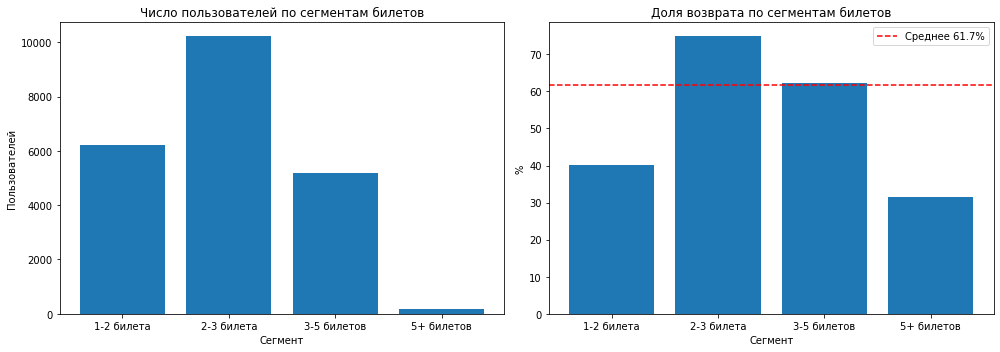

In [72]:
# визуализация: число пользователей и доля возврата по сегментам
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(ticket_seg_stats['ticket_seg'].astype(str), ticket_seg_stats['users'])
ax1.set_title('Число пользователей по сегментам билетов')
ax1.set_xlabel('Сегмент')
ax1.set_ylabel('Пользователей')

ax2.bar(ticket_seg_stats['ticket_seg'].astype(str), ticket_seg_stats['return_rate_%'])
ax2.axhline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
ax2.set_title('Доля возврата по сегментам билетов')
ax2.set_xlabel('Сегмент')
ax2.set_ylabel('%')
ax2.legend()

plt.tight_layout()
plt.show()

**Вывод по задаче 4.2.3**

Пользователи сконцентрированы в сегменте 1-2 билета - это подавляющее большинство. Сегменты с большим числом билетов (3-5 и 5+) содержат значительно меньше пользователей. Доля повторных покупок может отличаться между сегментами: пользователи, покупающие больше билетов за раз, могут демонстрировать более высокую или более низкую лояльность - это зависит от характера мероприятий.

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

День недели и доля возврата:
first_dow_name  users  return_rate_%
            Пн   2938          63.17
            Вт   3187          62.19
            Ср   3066          62.17
            Чт   3112          59.45
            Пт   3246          59.67
            Сб   3453          64.44
            Вс   2813          60.22


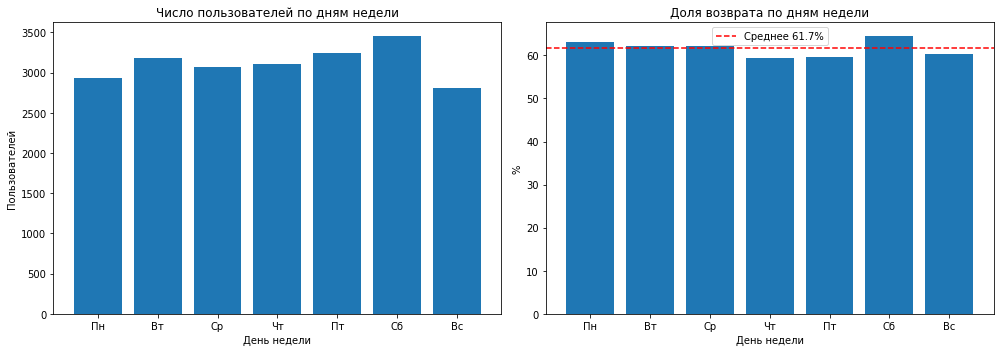

In [73]:
# выделяем день недели первой покупки
profile['first_dow'] = pd.to_datetime(profile['first_order_dt']).dt.dayofweek
day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
profile['first_dow_name'] = profile['first_dow'].map(day_names)

dow_stats = profile.groupby(['first_dow', 'first_dow_name']).agg(
    users=('user_id', 'count'),
    returned=('is_two', 'sum')
).reset_index().sort_values('first_dow')
dow_stats['return_rate_%'] = (dow_stats['returned'] / dow_stats['users'] * 100).round(2)

print('День недели и доля возврата:')
print(dow_stats[['first_dow_name', 'users', 'return_rate_%']].to_string(index=False))

# визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(dow_stats['first_dow_name'], dow_stats['users'])
ax1.set_title('Число пользователей по дням недели')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Пользователей')
ax2.bar(dow_stats['first_dow_name'], dow_stats['return_rate_%'])
ax2.axhline(overall_return, color='red', linestyle='--', label=f'Среднее {overall_return:.1f}%')
ax2.set_title('Доля возврата по дням недели')
ax2.set_xlabel('День недели')
ax2.set_ylabel('%')
ax2.legend()
plt.tight_layout()
plt.show()

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

In [74]:
# сравниваем средний интервал между заказами для двух групп
days_2_4 = profile[(profile['total_orders'] >= 2) & (profile['total_orders'] <= 4)]['avg_days_between'].dropna()
days_5plus = profile[profile['total_orders'] >= 5]['avg_days_between'].dropna()

print(f'Группа 2-4 заказа: n={len(days_2_4)}, mean={days_2_4.mean():.1f} дней, median={days_2_4.median():.1f} дней')
print(f'Группа 5+ заказов: n={len(days_5plus)}, mean={days_5plus.mean():.1f} дней, median={days_5plus.median():.1f} дней')

Группа 2-4 заказа: n=7144, mean=21.0 дней, median=9.0 дней
Группа 5+ заказов: n=6306, mean=9.3 дней, median=7.4 дней


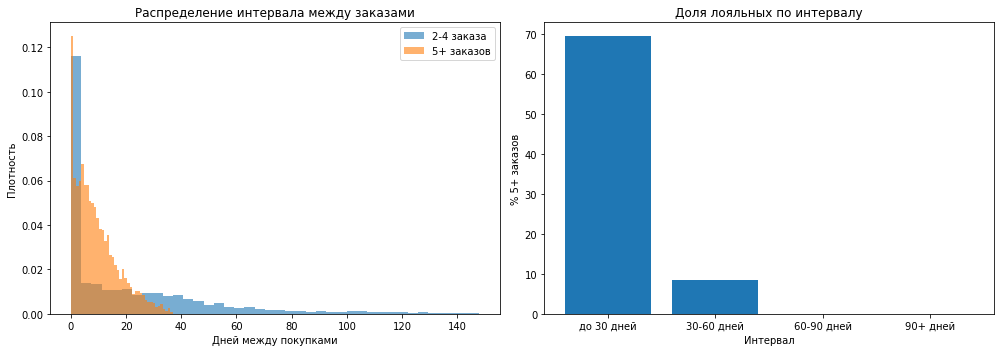

In [75]:
# визуализация распределения интервалов для двух групп
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(days_2_4, bins=40, alpha=0.6, density=True, label='2-4 заказа')
axes[0].hist(days_5plus, bins=40, alpha=0.6, density=True, label='5+ заказов')
axes[0].set_xlabel('Дней между покупками')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].set_title('Распределение интервала между заказами')

# сегменты по интервалу
bins_days = [0, 30, 60, 90, float('inf')]
labels_days = ['до 30 дней', '30-60 дней', '60-90 дней', '90+ дней']
returned_users = profile[profile['total_orders'] >= 2].copy()
returned_users = returned_users.dropna(subset=['avg_days_between'])
returned_users['interval_seg'] = pd.cut(returned_users['avg_days_between'], bins=bins_days, labels=labels_days)

interval_stats = returned_users.groupby('interval_seg').agg(
    users=('user_id', 'count'),
    loyal=('is_five', 'sum')
).reset_index()
interval_stats['loyal_rate_%'] = (interval_stats['loyal'] / interval_stats['users'] * 100).round(2)

axes[1].bar(interval_stats['interval_seg'].astype(str), interval_stats['loyal_rate_%'])
axes[1].set_title('Доля лояльных по интервалу')
axes[1].set_xlabel('Интервал')
axes[1].set_ylabel('% 5+ заказов')
plt.tight_layout()
plt.show()

**Вывод по задаче 4.3.2**

Пользователи с 5+ заказами в среднем возвращаются быстрее, чем те, кто сделал 2-4 заказа. Пользователи с коротким интервалом (до 30 дней) чаще оказываются лояльными: они активно посещают мероприятия и являются ценной аудиторией для удержания. Чем больше интервал, тем ниже доля пользователей с 5+ заказами - это говорит о том, что частота посещений напрямую связана с лояльностью.

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

In [76]:
# устанавливаем phik
try:
    import phik
    from phik import phik_matrix
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'phik', '-q'])
    import phik
    from phik import phik_matrix

# признаки для корреляции
corr_cols = ['first_event_type', 'first_device', 'first_region', 'first_service',
             'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
             'first_dow', 'total_orders']
profile_corr = profile[corr_cols].copy()

# интервальные столбцы
interval_cols = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'first_dow', 'total_orders']

# считаем phi_k матрицу
phik_mat = profile_corr.phik_matrix(interval_cols=interval_cols)
print('Матрица phi_k составлена')

# смотрим корреляцию с total_orders
total_orders_corr = phik_mat['total_orders'].drop('total_orders').sort_values(ascending=False)
print('\nКорреляция признаков с total_orders:')
print(total_orders_corr.round(3))

Матрица phi_k составлена

Корреляция признаков с total_orders:
first_region         0.126
first_service        0.100
first_dow            0.056
avg_revenue_rub      0.044
first_event_type     0.000
first_device         0.000
avg_tickets_count    0.000
avg_days_between     0.000
Name: total_orders, dtype: float64


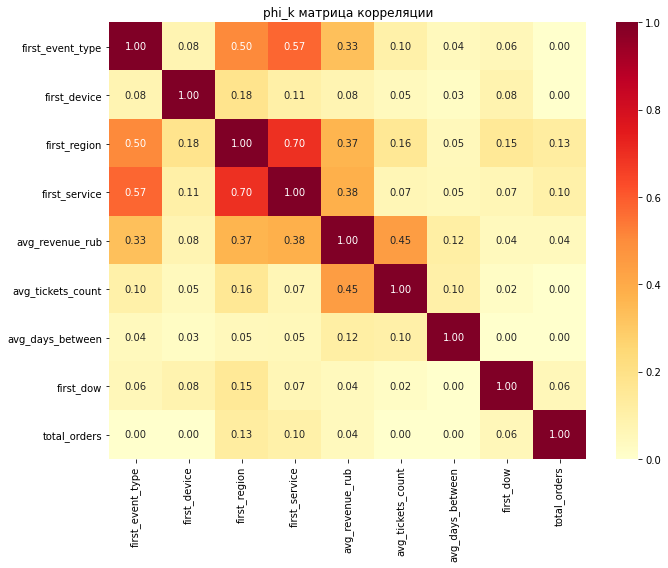

In [77]:
# тепловая карта phi_k корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(phik_mat, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('phi_k матрица корреляции')
plt.tight_layout()
plt.show()

In [78]:
# дополнительно: корреляция по сегментам total_orders
profile['order_seg'] = pd.cut(
    profile['total_orders'],
    bins=[0, 1, 4, float('inf')],
    labels=['1 заказ', '2-4 заказа', '5+ заказов']
)

# анализируем только сегменты с разбросом в total_orders (2-4 и 5+)
for seg in ['2-4 заказа', '5+ заказов']:
    mask = profile['order_seg'] == seg
    seg_data = profile.loc[mask, corr_cols].copy()
    if len(seg_data) < 10:
        print(f'\n--- {seg} --- (слишком мало данных, пропускаем)')
        continue
    seg_corr = seg_data.phik_matrix(interval_cols=interval_cols)
    seg_total = seg_corr['total_orders'].drop('total_orders').sort_values(ascending=False)
    print(f'\n--- {seg} (n={len(seg_data)}) ---')
    print(seg_total.round(3).to_string())


--- 2-4 заказа (n=7144) ---
avg_days_between     0.385
avg_tickets_count    0.370
avg_revenue_rub      0.104
first_service        0.073
first_device         0.035
first_event_type     0.000
first_region         0.000
first_dow            0.000

--- 5+ заказов (n=6306) ---
first_region         0.281
first_service        0.111
first_dow            0.094
avg_days_between     0.061
avg_revenue_rub      0.023
first_event_type     0.000
first_device         0.000
avg_tickets_count    0.000


**Вывод по задаче 4.4.1**

В сегменте 2-4 заказа наибольшую связь с числом покупок показывают средний интервал между заказами (phi_k = 0,39) и среднее число билетов (phi_k = 0,37), пользователи, которые возвращаются быстрее и покупают больше билетов, склонны совершать больше заказов. Средняя выручка имеет слабую связь (0,11), а категориальные признаки первого заказа практически не влияют. В сегменте 5+ заказов картина меняется: ведущим фактором становится регион первого заказа (phi_k = 0,28) - в определенных регионах формируется устойчивая лояльная аудитория. Билетный оператор (0,11) и день недели первого заказа (0,09) тоже имеют умеренную связь. При этом количественные метрики (выручка, билеты, интервал) теряют значимость - среди активных пользователей они уже более однородны. Таким образом, на ранних этапах удержания (2-4 заказа) важнее поведенческие метрики (частота и размер заказов), а для формирования глубокой лояльности (5+) ключевую роль играют географические и партнерские факторы.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# Общий вывод и рекомендации

### Информация о данных
Для анализа были использованы данные о покупках на Яндекс Афише за период с июня по октябрь 2024 года. В процессе подготовки данных:
- Выручка в тенге была переведена в рубли по актуальному курсу.
- Проведена очистка от выбросов по выручке (99-й перцентиль), что позволило убрать аномально дорогие заказы.
- Сформированы профили пользователей с ключевыми метриками: дата первого заказа, средний чек, количество билетов и интервал между покупками.

### Основные результаты
1. **Репрезентативность:** В выборке 21 815 уникальных пользователей и 289 194 заказа за период июнь–октябрь 2024 года. Доля пользователей с повторными заказами (2+) - 61,65%, с 5+ заказами - 28,91%. Средняя выручка с заказа - 524,48 руб.
2. **Точки входа:** Концерты - главная точка входа (43,7% пользователей), далее идет "другое" (25,3%) и театр (19,8%). По доле возврата лидируют выставки (64,3%) и театр (63,9%), тогда как "спорт" показывает возврат ниже среднего (55,9%). Гипотеза о превосходстве спорта над концертами не подтвердилась - у концертов доля возврата выше (62,0% против 55,9%).
3. **Устройства**: 82,5% пользователей приходят с мобильных, но десктоп показывает чуть более высокую долю возврата (64,1% против 61,2%).
4. **Чеки и билеты:** Средняя выручка практически не различается между одноразовыми (526 руб.) и вернувшимися (523 руб.) пользователями. Зато число билетов влияет на возврат: сегмент 2-3 билета показывает максимальную долю возврата (74,9%), а 5+ билетов - минимальную (31,5%).
5. **Временные факторы**: День недели первого заказа слабо влияет на возврат (разброс 59,5 между 64,4%). Ключевой фактор - интервал между покупками: у лояльных пользователей (5+) он составляет в среднем 9,3 дня против 21,0 дня у группы 2-4 заказа.
6. **Корреляционный анализ:** В сегменте 2-4 заказа главные предикторы количества покупок - интервал между заказами (phi_k = 0,39) и число билетов (0,37). В сегменте 5+ на первое место выходит регион (phi_k = 0,28) - в определенных регионах формируется устойчивая лояльная аудитория.

### Рекомендации
- **Фокус на «быстрый возврат»:** Лояльные пользователи возвращаются в среднем через 9 дней. Стимулируйте повторную покупку в первые 2-3 недели после первого заказа (push-уведомления, персональные подборки).
- **Развитие театра и выставок:** Эти жанры дают самую высокую долю возврата (63,9% и 64,3%), стоит увеличивать их предложение.
- **Сегмент 2–3 билета — золотая середина**: Показывает максимальный возврат (74,9%). Стоит стимулировать покупку парных/семейных билетов.
- **Региональный фокус:** В сегменте лояльных пользователей регион — главный предиктор числа заказов. Усильте маркетинг в регионах с высоким потенциалом.
- **Работа со спортивной аудиторией:** Несмотря на ожидания, спорт показывает возврат ниже среднего (55,9%). Нужны дополнительные механики удержания для этого сегмента.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

In [ ]:
https://darkpatus.github.io/yandex-afisha-project